<a href="https://colab.research.google.com/github/kartikmeghwal75/CODESOFT/blob/main/project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Building
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("/content/spam[1].csv", encoding='latin1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1','v2']]

df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print(df.shape)

print(df['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [5]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

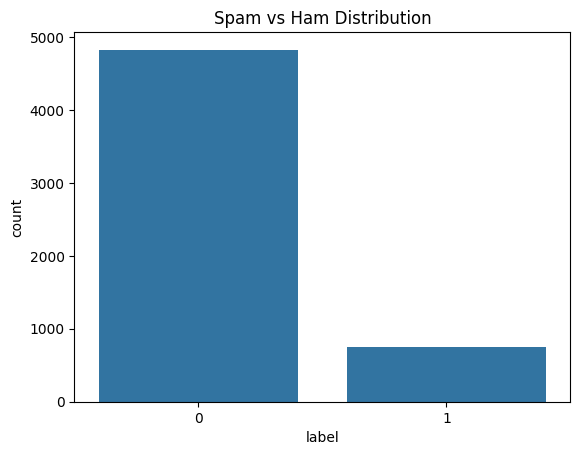

In [6]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

In [7]:
df['length'] = df['message'].apply(len)

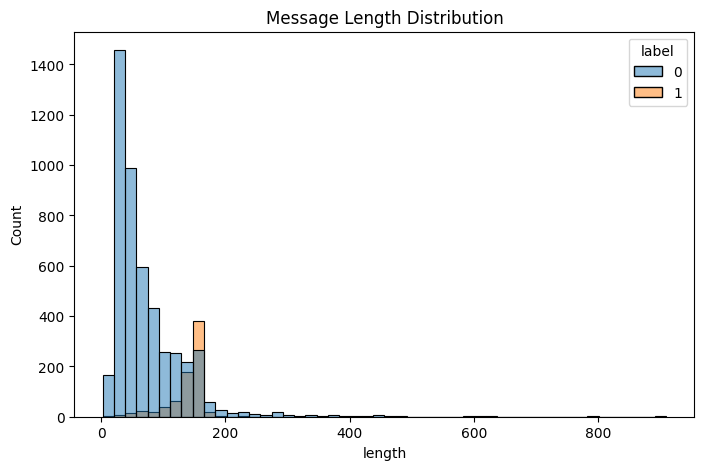

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

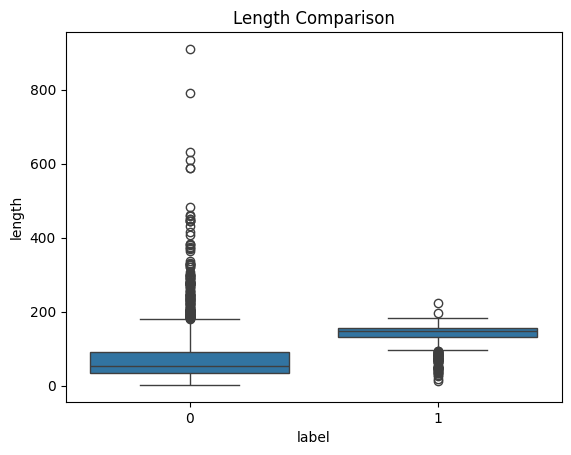

In [9]:
sns.boxplot(
    x='label',
    y='length',
    data=df
)

plt.title("Length Comparison")
plt.show()

In [10]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['message'])

y = df['label']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [13]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_nb))

print(classification_report(
      y_test,
      y_pred_nb))

Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.90       150

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



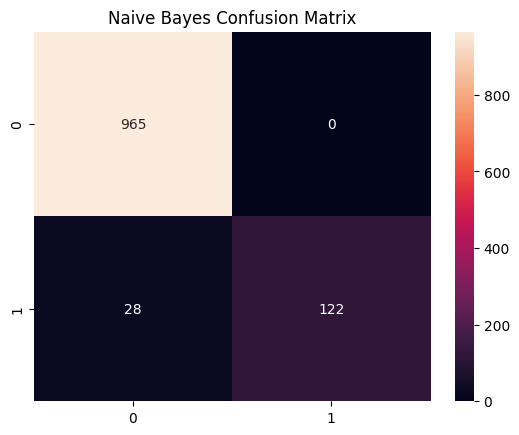

In [14]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [15]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(
      y_test,
      y_pred_lr))

Accuracy: 0.9488789237668162
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.64      0.77       150

    accuracy                           0.95      1115
   macro avg       0.96      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115



In [17]:
svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [18]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print(classification_report(
      y_test,
      y_pred_svm))

Accuracy: 0.9739910313901345
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.84      0.90       150

    accuracy                           0.97      1115
   macro avg       0.97      0.92      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [19]:
results = pd.DataFrame({
    'Model':[
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
    ],
    'Accuracy':[
        accuracy_score(y_test,y_pred_nb),
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_svm)
    ]
})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.974888
1  Logistic Regression  0.948879
2                  SVM  0.973991


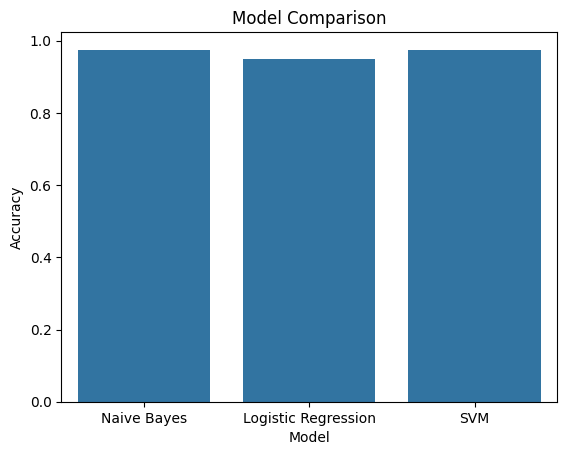

In [20]:
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Comparison")
plt.show()

In [24]:
msg = ["URGENT! Your account has been selected to receive a $1000 cash prize. Reply WIN now"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


In [25]:
msg = ["Free entry in a weekly competition. Text WIN to 80086 now"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


In [27]:
msg = ["Congratulations! You have won a FREE iPhone. Call now"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [28]:
msg = ["URGENT! Your account has been selected to receive a $1000 cash prize. Reply WIN now"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


In [29]:
msg = ["Hey, are we still meeting for lunch today?"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [30]:
msg = ["Please send me the notes from yesterday's class"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [31]:
msg = ["Mom, I reached home safely"]

msg_vector = tfidf.transform(msg)

prediction = svm.predict(msg_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Ham


In [32]:
messages = [
    "Congratulations! You won a free vacation package.",
    "Can you call me when you are free?",
    "Exclusive offer! Claim your reward now.",
    "Meeting has been shifted to 3 PM.",
    "You have won a cash prize. Reply YES."
]

msg_vector = tfidf.transform(messages)

predictions = svm.predict(msg_vector)

for msg, pred in zip(messages, predictions):
    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print("-" * 50)

Message: Congratulations! You won a free vacation package.
Prediction: Spam
--------------------------------------------------
Message: Can you call me when you are free?
Prediction: Spam
--------------------------------------------------
Message: Exclusive offer! Claim your reward now.
Prediction: Spam
--------------------------------------------------
Message: Meeting has been shifted to 3 PM.
Prediction: Ham
--------------------------------------------------
Message: You have won a cash prize. Reply YES.
Prediction: Spam
--------------------------------------------------


In [33]:
messages = [
    "Congratulations! You won a free vacation package.",
    "Can you call me when you are free?",
    "Exclusive offer! Claim your reward now.",
    "Meeting has been shifted to 3 PM.",
    "You have won a cash prize. Reply YES."
]

msg_vector = tfidf.transform(messages)

predictions = svm.predict(msg_vector)

for msg, pred in zip(messages, predictions):
    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print("-" * 50)

Message: Congratulations! You won a free vacation package.
Prediction: Spam
--------------------------------------------------
Message: Can you call me when you are free?
Prediction: Spam
--------------------------------------------------
Message: Exclusive offer! Claim your reward now.
Prediction: Spam
--------------------------------------------------
Message: Meeting has been shifted to 3 PM.
Prediction: Ham
--------------------------------------------------
Message: You have won a cash prize. Reply YES.
Prediction: Spam
--------------------------------------------------


In [42]:
# Enter out and chekc it


user_msg = input("Enter SMS: ")

msg_vector = tfidf.transform([user_msg])

prediction = svm.predict(msg_vector)

print("\nPrediction:")

if prediction[0] == 1:
    print("🚨 Spam Message")
else:
    print("✅ Legitimate (Ham) Message")

Enter SMS: free fuck

Prediction:
✅ Legitimate (Ham) Message


In [41]:
messages = [
    "Congratulations! You won a free vacation package.",
    "Can you call me when you are free?",
    "Exclusive offer! Claim your reward now.",
    "Meeting has been shifted to 3 PM.",
    "You have won a cash prize. Reply YES.",
     "Hey, are we still meeting for lunch today?",
    "Please send me the notes from yesterday's class.",
    "Mom, I reached home safely.",
    "Can you call me when you are free?",
    "The meeting has been moved to 3 PM.",
    "Happy Birthday! Have a wonderful day.",
    "Don't forget to bring your laptop tomorrow.",
    "I have emailed you the project report.",
    "Let's meet at the library after class.",
    "Your order has been delivered successfully.",
    "Can you help me with the assignment?",
    "I'm running late, will arrive in 10 minutes.",
    "Please check the attached document.",
    "Thank you for your support and guidance.",
    "The exam schedule has been released.",
    "Good morning! Hope you have a great day.",
    "I'll call you after my lecture ends.",
    "Let's watch a movie this weekend.",
    "Where are you? We are waiting for you.",
    "The train will arrive at 7:30 PM.",
    "Congratulations! You have won a FREE iPhone. Call now.",
    "URGENT! Claim your ₹50,000 cash reward today.",
    "You have been selected for a free vacation package. Reply YES.",
    "Win a brand new car! Text WIN to 80808.",
    "Exclusive offer! Get 90% discount on all products.",
    "Your account has won a lottery worth $10,000.",
    "Free entry into our weekly competition. Join now.",
    "Congratulations! You are our lucky winner today.",
    "Limited-time offer! Buy one get one free.",
    "You have won a free movie ticket. Click here.",
    "Claim your free gift card before it expires.",
    "Act now! Lowest loan rates available today.",
    "Earn ₹10,000 per day working from home.",
    "Get rich fast! Register now and start earning.",
    "Your mobile number has won a lucky draw prize.",
    "Click this link to receive your reward instantly.",
    "You have been pre-approved for a personal loan.",
    "Free recharge worth ₹500 available today.",
    "Special promotion! Receive cash rewards instantly.",
    "Winner! Contact us immediately to claim your prize."

]

msg_vector = tfidf.transform(messages)

predictions = svm.predict(msg_vector)

for msg, pred in zip(messages, predictions):
    print(f"Message: {msg}")
    print("Prediction:", "Spam" if pred == 1 else "Ham")
    print("-" * 50)

Message: Congratulations! You won a free vacation package.
Prediction: Spam
--------------------------------------------------
Message: Can you call me when you are free?
Prediction: Spam
--------------------------------------------------
Message: Exclusive offer! Claim your reward now.
Prediction: Spam
--------------------------------------------------
Message: Meeting has been shifted to 3 PM.
Prediction: Ham
--------------------------------------------------
Message: You have won a cash prize. Reply YES.
Prediction: Spam
--------------------------------------------------
Message: Hey, are we still meeting for lunch today?
Prediction: Ham
--------------------------------------------------
Message: Please send me the notes from yesterday's class.
Prediction: Ham
--------------------------------------------------
Message: Mom, I reached home safely.
Prediction: Ham
--------------------------------------------------
Message: Can you call me when you are free?
Prediction: Spam
----------

## Conclusion

We have successfully built, trained, and evaluated multiple machine learning models (Naive Bayes, Logistic Regression, and SVM) for spam detection. The models demonstrated high accuracy, with SVM showing strong performance in classifying messages as spam or ham. This project highlights the effectiveness of text processing and machine learning in tackling real-world problems like unwanted messages.